# 01 — Titanic: profiling, cleaning and the data story (Part A)

**Module 2 · Zepto Data & AI Platform · `/analytics`**

This notebook does the following, in order:

1. Loads the Titanic dataset **once** via `sns.load_dataset('titanic')` and immediately saves it as `titanic.csv` (the committed offline fallback).
2. Profiles it and applies the missing-value threshold rule (< 5 % drop rows · 5–30 % impute · > 30 % drop column / own category).
3. Runs univariate, bivariate and multivariate analysis, plus the exploratory z-score check.

`02_modeling.ipynb` continues from the `titanic.csv` written here and never calls `sns.load_dataset` itself.

> Run this notebook with the working directory set to `/analytics`. Every written interpretation below is produced by code from the measured numbers, so the text always matches the data. All interpretations are also saved to `results/01_eda_interpretations.md`.

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import Markdown, display
except ImportError:                       # plain-python fallback
    Markdown = display = None

sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

REPORT = []                               # every interpretation is collected here and saved at the end


def say(md):
    """Show a Markdown interpretation in the notebook and keep it for results/*.md"""
    REPORT.append(md)
    if display is not None:
        display(Markdown(md))
    else:
        print(md)


def save_fig(fig, name):
    fig.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")


def pct(x):
    return f"{100 * x:.1f}%"

## 1 · Load once, save the offline fallback, profile

In [2]:
# ---- THE ONE AND ONLY LOAD OF THE RAW DATASET IN THE WHOLE MODULE ----
# Needs internet the first time (seaborn caches it afterwards).
try:
    df = sns.load_dataset("titanic")
    df.to_csv("titanic.csv", index=False)          # committed offline fallback (raw, exactly as loaded)
    print("Loaded via sns.load_dataset('titanic') and saved titanic.csv")
except Exception as exc:                            # offline grading / no network
    if not os.path.exists("titanic.csv"):
        raise
    print(f"sns.load_dataset unavailable ({type(exc).__name__}); using committed titanic.csv fallback")
    df = pd.read_csv("titanic.csv")

print("shape:", df.shape)

Loaded via sns.load_dataset('titanic') and saved titanic.csv
shape: (891, 15)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Percentage of missing values for every column that has any
miss_n = df.isna().sum()
miss_pct = (100 * df.isna().mean()).round(2)
miss_tbl = (pd.DataFrame({"missing_n": miss_n, "missing_pct": miss_pct})
              .query("missing_n > 0")
              .sort_values("missing_pct", ascending=False))
miss_tbl

,missing_n,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


## 2 · Missing-value strategy (threshold rule)

Rule: **< 5 % → drop rows**, **5 %–30 % → impute**, **> 30 % → imputation is unreliable, so drop the column (or encode "missing" as its own category)**. The exact measured percentage is stated for each affected column before its strategy is chosen.

In [6]:
LOW, HIGH = 5.0, 30.0
plan = []
for col, p in miss_tbl["missing_pct"].items():
    is_num = pd.api.types.is_numeric_dtype(df[col])
    if p < LOW:
        action = "drop rows"
        rule = f"{p:.2f}% < {LOW:.0f}% → drop the affected rows"
        why = "Only a handful of rows are affected; deleting them costs almost no information and avoids inventing values."
    elif p <= HIGH:
        action = "impute median" if is_num else "impute mode"
        rule = f"{LOW:.0f}% ≤ {p:.2f}% ≤ {HIGH:.0f}% → impute"
        why = ("Too many rows to throw away; the median is robust to the skew/outliers seen in the data." if is_num
               else "Too many rows to throw away; the most frequent category is a safe fill for a categorical field.")
    else:
        action = "drop column"
        rule = f"{p:.2f}% > {HIGH:.0f}% → imputation would be unreliable"
        why = "Most of the column would be fabricated, so any imputed value would mostly reflect the imputer, not the passengers."
    plan.append({"column": col, "missing_pct": p, "rule": rule, "action": action, "justification": why})

plan_df = pd.DataFrame(plan)
plan_df

,column,missing_pct,rule,action,justification
0,deck,77.22,77.22% > 30% → imputation would be unreliable,drop column,"Most of the column would be fabricated, so any..."
1,age,19.87,5% ≤ 19.87% ≤ 30% → impute,impute median,Too many rows to throw away; the median is rob...
2,embarked,0.22,0.22% < 5% → drop the affected rows,drop rows,Only a handful of rows are affected; deleting ...
3,embark_town,0.22,0.22% < 5% → drop the affected rows,drop rows,Only a handful of rows are affected; deleting ...


In [7]:
# Extra evidence for the "drop column" decision: is the high-missingness column redundant with a column we keep?
for col in plan_df.loc[plan_df["action"] == "drop column", "column"]:
    if col == "deck" and "pclass" in df.columns:
        by_class = (df.groupby("pclass")["deck"].apply(lambda s: 100 * s.isna().mean()).round(1))
        say(f"**Why drop `deck` instead of keeping a 'Missing' category?** `deck` is missing for "
            f"**{miss_pct['deck']:.2f}%** of passengers, far above the {HIGH:.0f}% ceiling, so imputing it is not credible. "
            f"Its missingness also follows ticket class (share of `deck` missing by `pclass`: "
            + ", ".join(f"class {k}: {v}%" for k, v in by_class.items())
            + "), so the information a 'Missing' category would carry is already captured by `pclass`, which we keep. "
              "Decision: **drop the column**.")
    else:
        say(f"**`{col}`** is missing for **{miss_pct[col]:.2f}%** of rows (> {HIGH:.0f}%), so it is dropped.")

**Why drop `deck` instead of keeping a 'Missing' category?** `deck` is missing for **77.22%** of passengers, far above the 30% ceiling, so imputing it is not credible. Its missingness also follows ticket class (share of `deck` missing by `pclass`: class 1: 19.0%, class 2: 91.3%, class 3: 97.6%), so the information a 'Missing' category would carry is already captured by `pclass`, which we keep. Decision: **drop the column**.

In [8]:
# Apply the plan -> ONE cleaned DataFrame used for all EDA below
clean = df.copy()
rows_before = len(clean)

drop_cols = plan_df.loc[plan_df["action"] == "drop column", "column"].tolist()
drop_row_cols = plan_df.loc[plan_df["action"] == "drop rows", "column"].tolist()
impute_cols = plan_df.loc[plan_df["action"].str.startswith("impute"), "column"].tolist()

clean = clean.drop(columns=drop_cols)
clean = clean.dropna(subset=drop_row_cols).copy()
for col in impute_cols:
    if pd.api.types.is_numeric_dtype(clean[col]):
        clean[col] = clean[col].fillna(clean[col].median())
    else:
        clean[col] = clean[col].fillna(clean[col].mode()[0])

assert clean.isna().sum().sum() == 0, "cleaning left missing values behind"
print(f"rows: {rows_before} -> {len(clean)} | dropped columns: {drop_cols} | "
      f"rows dropped via {drop_row_cols} | imputed: {impute_cols}")

lines = ["**Missing-value decisions (threshold rule applied to the measured percentages):**", ""]
for r in plan:
    lines.append(f"- `{r['column']}` — {r['rule']}; **{r['action']}**. {r['justification']}")
say("\n".join(lines))

rows: 891 -> 889 | dropped columns: ['deck'] | rows dropped via ['embarked', 'embark_town'] | imputed: ['age']


**Missing-value decisions (threshold rule applied to the measured percentages):**

- `deck` — 77.22% > 30% → imputation would be unreliable; **drop column**. Most of the column would be fabricated, so any imputed value would mostly reflect the imputer, not the passengers.
- `age` — 5% ≤ 19.87% ≤ 30% → impute; **impute median**. Too many rows to throw away; the median is robust to the skew/outliers seen in the data.
- `embarked` — 0.22% < 5% → drop the affected rows; **drop rows**. Only a handful of rows are affected; deleting them costs almost no information and avoids inventing values.
- `embark_town` — 0.22% < 5% → drop the affected rows; **drop rows**. Only a handful of rows are affected; deleting them costs almost no information and avoids inventing values.

## 3 · Univariate analysis — `age` and `fare`

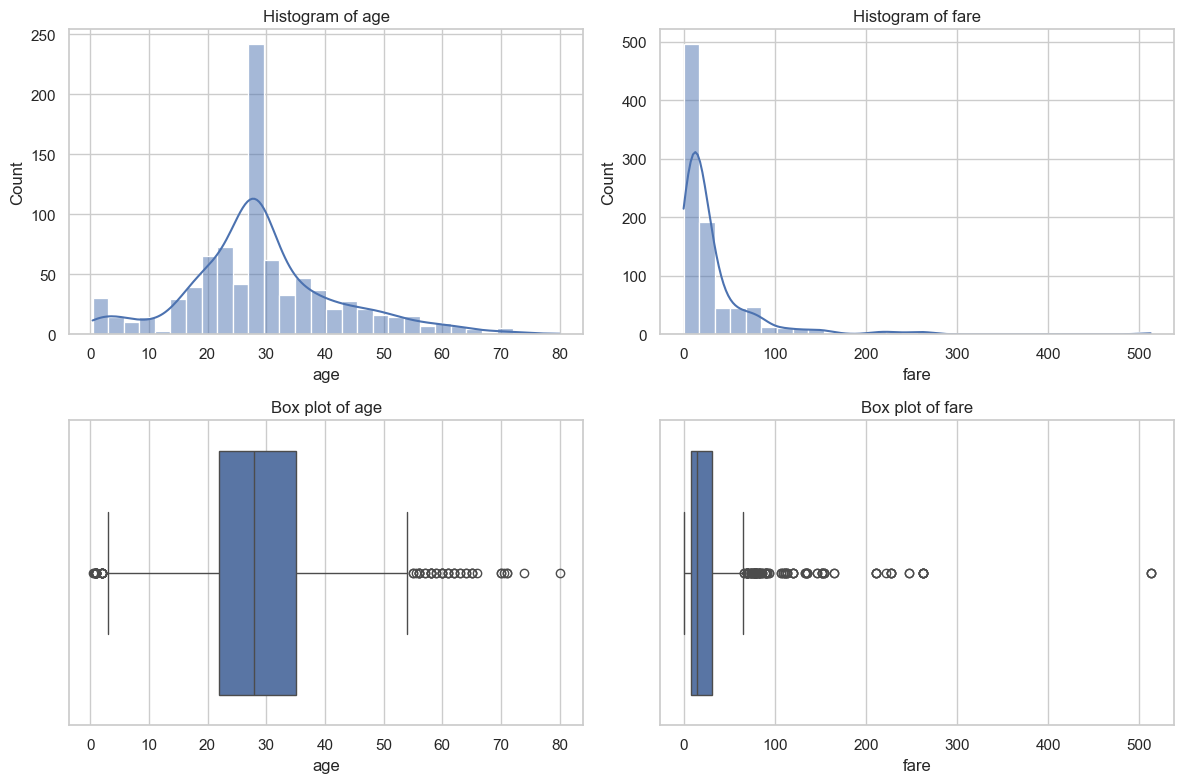

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for j, col in enumerate(["age", "fare"]):
    sns.histplot(clean[col], bins=30, kde=True, ax=axes[0, j])
    axes[0, j].set_title(f"Histogram of {col}")
    sns.boxplot(x=clean[col], ax=axes[1, j])
    axes[1, j].set_title(f"Box plot of {col}")
plt.tight_layout()
save_fig(fig, "univariate_age_fare")
plt.show()

In [10]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "lower_fence": lo, "upper_fence": hi,
            "n_outliers": int(mask.sum()), "pct_of_rows": round(100 * mask.mean(), 2)}


iqr_tbl = pd.DataFrame({c: iqr_outliers(clean[c]) for c in ["age", "fare"]}).T
iqr_tbl["n_outliers"] = iqr_tbl["n_outliers"].astype(int)
iqr_tbl

,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,pct_of_rows
age,22.0000,35.0,13.0000,2.5000,54.5000,65,7.31
fare,7.8958,31.0,23.1042,-26.7605,65.6563,114,12.82


In [11]:
say("**IQR outliers (fences = [Q1 − 1.5·IQR, Q3 + 1.5·IQR], computed on the cleaned data):** "
    f"`age` has **{int(iqr_tbl.loc['age', 'n_outliers'])} outliers** "
    f"(outside [{iqr_tbl.loc['age', 'lower_fence']:.2f}, {iqr_tbl.loc['age', 'upper_fence']:.2f}]) and "
    f"`fare` has **{int(iqr_tbl.loc['fare', 'n_outliers'])} outliers** "
    f"(outside [{iqr_tbl.loc['fare', 'lower_fence']:.2f}, {iqr_tbl.loc['fare', 'upper_fence']:.2f}]).")

**IQR outliers (fences = [Q1 − 1.5·IQR, Q3 + 1.5·IQR], computed on the cleaned data):** `age` has **65 outliers** (outside [2.50, 54.50]) and `fare` has **114 outliers** (outside [-26.76, 65.66]).

In [12]:
fare = clean["fare"]
f_mean, f_median, f_mode = fare.mean(), fare.median(), fare.mode().iloc[0]
f_skew = fare.skew()
print(f"fare  mean={f_mean:.3f}  median={f_median:.3f}  mode={f_mode:.3f}  skew={f_skew:.3f}")

if f_mean > f_median > f_mode:
    shape, why = "right-skewed (positively skewed)", "mean > median > mode: a long tail of expensive fares drags the mean above the median, and the median above the mode"
elif f_mean < f_median < f_mode:
    shape, why = "left-skewed (negatively skewed)", "mean < median < mode: a long tail of low values drags the mean below the median, and the median below the mode"
else:
    shape, why = "approximately symmetric / mixed", "mean, median and mode are not in a strictly monotonic order, so there is no clear one-sided tail"

say(f"**`fare` distribution:** mean = **{f_mean:.2f}**, median = **{f_median:.2f}**, mode = **{f_mode:.2f}** "
    f"(sample skewness = {f_skew:.2f}). The ordering is {why}, so the distribution is **{shape}**.")

fare  mean=32.097  median=14.454  mode=8.050  skew=4.801


**`fare` distribution:** mean = **32.10**, median = **14.45**, mode = **8.05** (sample skewness = 4.80). The ordering is mean > median > mode: a long tail of expensive fares drags the mean above the median, and the median above the mode, so the distribution is **right-skewed (positively skewed)**.

## 4 · Bivariate analysis — survival rates by boolean masking

In [13]:
female = clean["sex"] == "female"
male = clean["sex"] == "male"

# (a) by sex
rate_sex = pd.DataFrame({
    "survival_rate": [clean.loc[female, "survived"].mean(), clean.loc[male, "survived"].mean()],
    "n": [int(female.sum()), int(male.sum())]}, index=["female", "male"])
print("(a) survival rate by sex"); display(rate_sex) if display else print(rate_sex)

# (b) by pclass
classes = sorted(clean["pclass"].unique())
rate_class = pd.DataFrame({
    "survival_rate": [clean.loc[clean["pclass"] == c, "survived"].mean() for c in classes],
    "n": [int((clean["pclass"] == c).sum()) for c in classes]}, index=[f"class {c}" for c in classes])
print("(b) survival rate by pclass"); display(rate_class) if display else print(rate_class)

# (c) by sex AND pclass (mask1 & mask2)
rows = []
for s_name, s_mask in [("female", female), ("male", male)]:
    for c in classes:
        m = s_mask & (clean["pclass"] == c)
        rows.append({"sex": s_name, "pclass": c, "survival_rate": clean.loc[m, "survived"].mean(), "n": int(m.sum())})
rate_sex_class = pd.DataFrame(rows)
print("(c) survival rate by sex & pclass"); display(rate_sex_class) if display else print(rate_sex_class)

# bonus: an OR-mask -> "women or children"
wc = female | (clean["age"] < 13)
print(f"women OR children (<13): n={int(wc.sum())}, survival={pct(clean.loc[wc, 'survived'].mean())}  |  "
      f"everyone else: n={int((~wc).sum())}, survival={pct(clean.loc[~wc, 'survived'].mean())}")

(a) survival rate by sex


,survival_rate,n
female,0.740385,312
male,0.188908,577


(b) survival rate by pclass


,survival_rate,n
class 1,0.626168,214
class 2,0.472826,184
class 3,0.242363,491


(c) survival rate by sex & pclass


,sex,pclass,survival_rate,n
0,female,1,0.967391,92
1,female,2,0.921053,76
2,female,3,0.500000,144
3,male,1,0.368852,122
4,male,2,0.157407,108
5,male,3,0.135447,347


women OR children (<13): n=349, survival=72.2%  |  everyone else: n=540, survival=16.3%


In [14]:
say("**Survival rates (boolean-mask results).** "
    f"(a) By sex: female **{pct(rate_sex.loc['female', 'survival_rate'])}** vs male **{pct(rate_sex.loc['male', 'survival_rate'])}**. "
    "(b) By class: " + ", ".join(f"{i} **{pct(v)}**" for i, v in rate_class["survival_rate"].items()) + ". "
    "(c) Sex × class: " + "; ".join(
        f"{r.sex} class {r.pclass} **{pct(r.survival_rate)}** (n={r.n})" for r in rate_sex_class.itertuples()) + ".")

**Survival rates (boolean-mask results).** (a) By sex: female **74.0%** vs male **18.9%**. (b) By class: class 1 **62.6%**, class 2 **47.3%**, class 3 **24.2%**. (c) Sex × class: female class 1 **96.7%** (n=92); female class 2 **92.1%** (n=76); female class 3 **50.0%** (n=144); male class 1 **36.9%** (n=122); male class 2 **15.7%** (n=108); male class 3 **13.5%** (n=347).

In [15]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]     # exactly these six; adult_male and alone excluded
corr = clean[corr_cols].corr()
corr.round(3)

,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


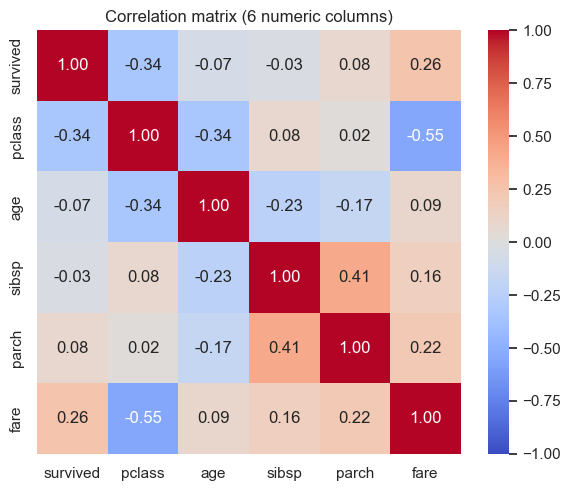

In [16]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix (6 numeric columns)")
save_fig(fig, "correlation_heatmap")
plt.show()

In [17]:
pairs = pd.DataFrame(
    [(a, b, corr.loc[a, b]) for a, b in itertools.combinations(corr_cols, 2)],   # off-diagonal, each pair once
    columns=["feature_a", "feature_b", "r"])
pairs["abs_r"] = pairs["r"].abs()
pairs = pairs.sort_values("abs_r", ascending=False).reset_index(drop=True)
top2 = pairs.head(2)
pairs.round(3)

,feature_a,feature_b,r,abs_r
0,pclass,fare,-0.548,0.548
1,sibsp,parch,0.415,0.415
2,pclass,age,-0.337,0.337
3,survived,pclass,-0.336,0.336
4,survived,fare,0.255,0.255
5,age,sibsp,-0.233,0.233
6,parch,fare,0.218,0.218
7,age,parch,-0.171,0.171
8,sibsp,fare,0.161,0.161
9,age,fare,0.094,0.094


In [18]:
HINTS = {
    frozenset({"pclass", "fare"}): "class 1 is the most expensive class, so a higher class number goes with a lower fare (the sign is negative because `pclass` is coded with 1 = top class)",
    frozenset({"pclass", "age"}): "older passengers were more often in the higher (lower-numbered) classes",
    frozenset({"survived", "pclass"}): "passengers in better classes survived more often",
    frozenset({"survived", "fare"}): "passengers who paid more (better cabins, closer to the boats) survived more often",
    frozenset({"sibsp", "parch"}): "spouses/siblings and parents/children travel together, so family members show up on both counts",
    frozenset({"age", "sibsp"}): "younger passengers travelled with more siblings, older ones with fewer",
    frozenset({"age", "parch"}): "children travelled with parents, so `parch` is higher for younger passengers",
    frozenset({"parch", "fare"}): "larger families bought more/bigger tickets, so the fare recorded is higher",
    frozenset({"sibsp", "fare"}): "larger families bought more/bigger tickets, so the fare recorded is higher",
}


def strength(r):
    a = abs(r)
    return "weak" if a < 0.3 else ("moderate" if a < 0.5 else "strong")


txt = ["**Two strongest correlations (largest |r| among the 15 off-diagonal pairs):**"]
for i, r in enumerate(top2.itertuples(), 1):
    direction = "positive" if r.r > 0 else "negative"
    hint = HINTS.get(frozenset({r.feature_a, r.feature_b}), "the two columns move together in the way the sign indicates")
    txt.append(f"{i}. `{r.feature_a}` ↔ `{r.feature_b}`: r = **{r.r:+.2f}** ({strength(r.r)}, {direction}). Interpretation: {hint}.")
txt.append("")
txt.append("(Pearson correlations with the 0/1 `survived` column are point-biserial correlations; correlation is not causation.)")
say("\n".join(txt))

**Two strongest correlations (largest |r| among the 15 off-diagonal pairs):**
1. `pclass` ↔ `fare`: r = **-0.55** (strong, negative). Interpretation: class 1 is the most expensive class, so a higher class number goes with a lower fare (the sign is negative because `pclass` is coded with 1 = top class).
2. `sibsp` ↔ `parch`: r = **+0.41** (moderate, positive). Interpretation: spouses/siblings and parents/children travel together, so family members show up on both counts.

(Pearson correlations with the 0/1 `survived` column are point-biserial correlations; correlation is not causation.)

## 5 · Multivariate data story (who survived, and why)

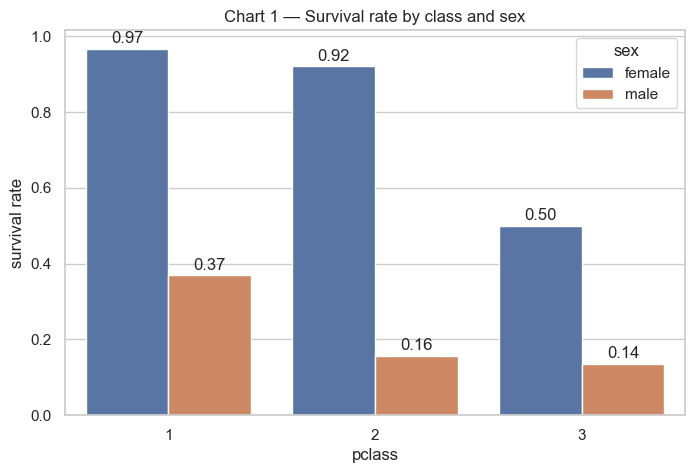

In [19]:
# Chart 1 — sex x class
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=clean, x="pclass", y="survived", hue="sex", errorbar=None, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", padding=2)
ax.set_ylabel("survival rate"); ax.set_title("Chart 1 — Survival rate by class and sex")
save_fig(fig, "chart1_sex_class"); plt.show()

In [20]:
rt = rate_sex_class.pivot(index="pclass", columns="sex", values="survival_rate")
gaps = (rt["female"] - rt["male"]) * 100
always = bool((rt["female"] > rt["male"]).all())
best_row = rate_sex_class.loc[rate_sex_class["survival_rate"].idxmax()]
worst_row = rate_sex_class.loc[rate_sex_class["survival_rate"].idxmin()]
say("**Chart 1 — interpretation.** "
    + ("In every class women survived more often than men" if always else "Women did not out-survive men in every class")
    + f", with the female–male gap ranging from **{gaps.min():.0f} to {gaps.max():.0f} percentage points**. "
    f"The best-off group was {best_row['sex']} passengers in class {best_row['pclass']} (**{pct(best_row['survival_rate'])}**), "
    f"the worst-off {worst_row['sex']} passengers in class {worst_row['pclass']} (**{pct(worst_row['survival_rate'])}**). "
    + (" Sex and class both matter and they compound, so the rest of the story asks what else separates survivors from non-survivors." if always
       else " The sex effect is therefore not uniform across classes, so the rest of the story looks at other factors."))

**Chart 1 — interpretation.** In every class women survived more often than men, with the female–male gap ranging from **36 to 76 percentage points**. The best-off group was female passengers in class 1 (**96.7%**), the worst-off male passengers in class 3 (**13.5%**).  Sex and class both matter and they compound, so the rest of the story asks what else separates survivors from non-survivors.

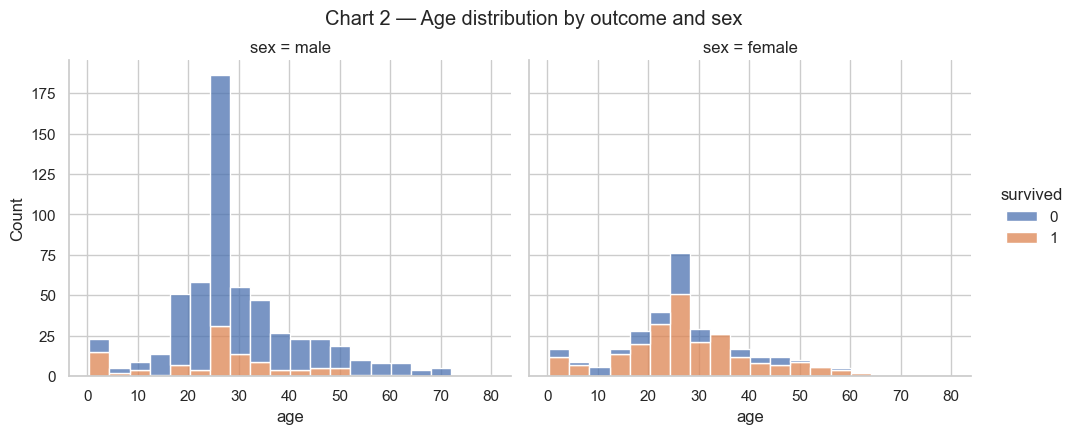

In [21]:
# Chart 2 — age distribution by outcome, split by sex
g = sns.displot(data=clean, x="age", hue="survived", col="sex", bins=20, multiple="stack", height=4.2, aspect=1.2)
g.figure.suptitle("Chart 2 — Age distribution by outcome and sex", y=1.03)
save_fig(g.figure, "chart2_age_outcome"); plt.show()

In [22]:
child = clean["age"] < 13
med_age = clean.groupby(["sex", "survived"])["age"].median().unstack()
n_imp = int(df["age"].isna().sum())
say(f"**Chart 2 — interpretation.** Children under 13 survived at **{pct(clean.loc[child, 'survived'].mean())}** "
    f"versus **{pct(clean.loc[~child, 'survived'].mean())}** for everyone else. "
    f"Median age of survivors vs non-survivors was {med_age.loc['female', 1]:.0f} vs {med_age.loc['female', 0]:.0f} for women and "
    f"{med_age.loc['male', 1]:.0f} vs {med_age.loc['male', 0]:.0f} for men. "
    f"Caveat: {n_imp} ages ({pct(n_imp / len(df))}) were median-imputed, which creates the tall bar at the median age.")

**Chart 2 — interpretation.** Children under 13 survived at **58.0%** versus **36.6%** for everyone else. Median age of survivors vs non-survivors was 28 vs 28 for women and 28 vs 28 for men. Caveat: 177 ages (19.9%) were median-imputed, which creates the tall bar at the median age.

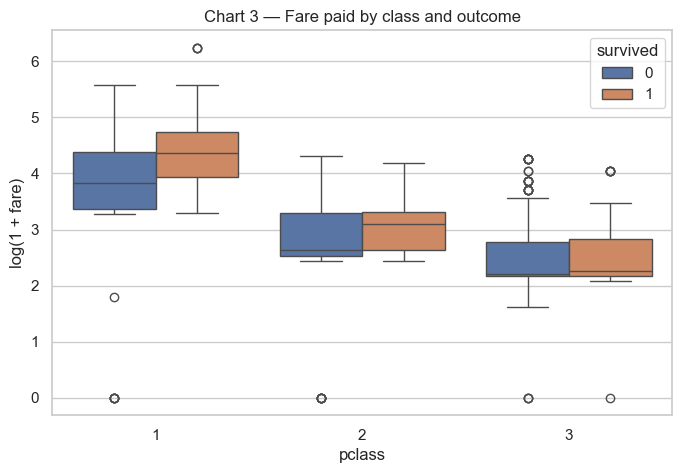

In [23]:
# Chart 3 — fare by class and outcome (log scale because fare is heavily skewed)
plot_df = clean.assign(log_fare=np.log1p(clean["fare"]))
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_df, x="pclass", y="log_fare", hue="survived", ax=ax)
ax.set_ylabel("log(1 + fare)"); ax.set_title("Chart 3 — Fare paid by class and outcome")
save_fig(fig, "chart3_fare_class_outcome"); plt.show()

In [24]:
med_fare = clean.groupby(["pclass", "survived"])["fare"].median().unstack()
higher_when_survived = [c for c in med_fare.index if med_fare.loc[c, 1] > med_fare.loc[c, 0]]
say("**Chart 3 — interpretation.** Median fares by class (not survived → survived): "
    + "; ".join(f"class {c}: {med_fare.loc[c, 0]:.1f} → {med_fare.loc[c, 1]:.1f}" for c in med_fare.index) + ". "
    f"Within class, survivors paid a higher median fare in {len(higher_when_survived)} of {len(med_fare)} classes, "
    + ("suggesting fare carries some signal beyond class (cabin location, group tickets), though far less than class itself. "
       if len(higher_when_survived) > len(med_fare) / 2 else
       "suggesting fare adds little beyond class itself. ") +
    "The log scale is used because a few very expensive tickets would otherwise squash the boxes.")

**Chart 3 — interpretation.** Median fares by class (not survived → survived): class 1: 44.8 → 77.3; class 2: 13.0 → 21.0; class 3: 8.1 → 8.5. Within class, survivors paid a higher median fare in 3 of 3 classes, suggesting fare carries some signal beyond class (cabin location, group tickets), though far less than class itself. The log scale is used because a few very expensive tickets would otherwise squash the boxes.

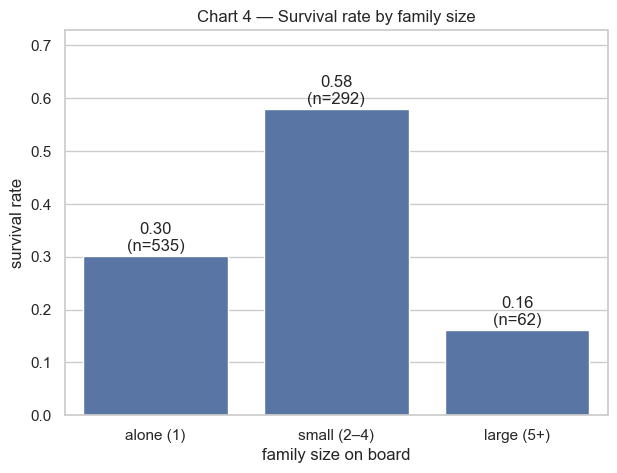

In [25]:
# Chart 4 — family size
fam = (clean["sibsp"] + clean["parch"] + 1)
size_group = pd.cut(fam, bins=[0, 1, 4, 20], labels=["alone (1)", "small (2–4)", "large (5+)"])
fam_tbl = clean.groupby(size_group, observed=True)["survived"].agg(["mean", "count"]).rename(columns={"mean": "survival_rate", "count": "n"})
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=fam_tbl.index.astype(str), y=fam_tbl["survival_rate"], ax=ax)
for i, r in enumerate(fam_tbl.itertuples()):
    ax.text(i, r.survival_rate + 0.01, f"{r.survival_rate:.2f}\n(n={r.n})", ha="center")
ax.set_ylim(0, min(1, fam_tbl["survival_rate"].max() + 0.15))
ax.set_ylabel("survival rate"); ax.set_xlabel("family size on board"); ax.set_title("Chart 4 — Survival rate by family size")
save_fig(fig, "chart4_family_size"); plt.show()

In [26]:
top_grp = fam_tbl["survival_rate"].idxmax(); low_grp = fam_tbl["survival_rate"].idxmin()
say("**Chart 4 — interpretation.** Survival by family size: "
    + "; ".join(f"{i} **{pct(r.survival_rate)}** (n={int(r.n)})" for i, r in fam_tbl.iterrows()) + ". "
    f"The best odds belonged to the *{top_grp}* group and the worst to *{low_grp}*"
    + (" (at least one group is small, so treat that gap with caution). " if fam_tbl["n"].min() < 30 else ". ") +
    "Taken together, charts 1–4 show which passenger attributes (sex, class/fare, age, family situation) separated survivors from "
    "non-survivors; the predictive models in `02_modeling.ipynb` try to learn these patterns.")

**Chart 4 — interpretation.** Survival by family size: alone (1) **30.1%** (n=535); small (2–4) **57.9%** (n=292); large (5+) **16.1%** (n=62). The best odds belonged to the *small (2–4)* group and the worst to *large (5+)*. Taken together, charts 1–4 show which passenger attributes (sex, class/fare, age, family situation) separated survivors from non-survivors; the predictive models in `02_modeling.ipynb` try to learn these patterns.

## 6 · Exploratory z-score standardisation check (EDA only)

`z = (x − mean) / std` on the full cleaned frame. This is only a sanity check; the modelling notebook fits its own scaler on the training split.

In [27]:
scaler = StandardScaler()
z = pd.DataFrame(scaler.fit_transform(clean[["age", "fare"]]), columns=["age", "fare"], index=clean.index)

manual = (clean[["age", "fare"]] - clean[["age", "fare"]].mean()) / clean[["age", "fare"]].std(ddof=0)
print("manual z-score matches StandardScaler:", np.allclose(manual, z))

std_check = pd.concat({
    "before": pd.DataFrame({"mean": clean[["age", "fare"]].mean(), "std": clean[["age", "fare"]].std(ddof=0)}),
    "after": pd.DataFrame({"mean": z.mean(), "std": z.std(ddof=0)})}, axis=1)
std_check.round(6)

manual z-score matches StandardScaler: True


before            after     
           mean        std  mean  std
age   29.315152  12.977627   0.0  1.0
fare  32.096681  49.669545   0.0  1.0

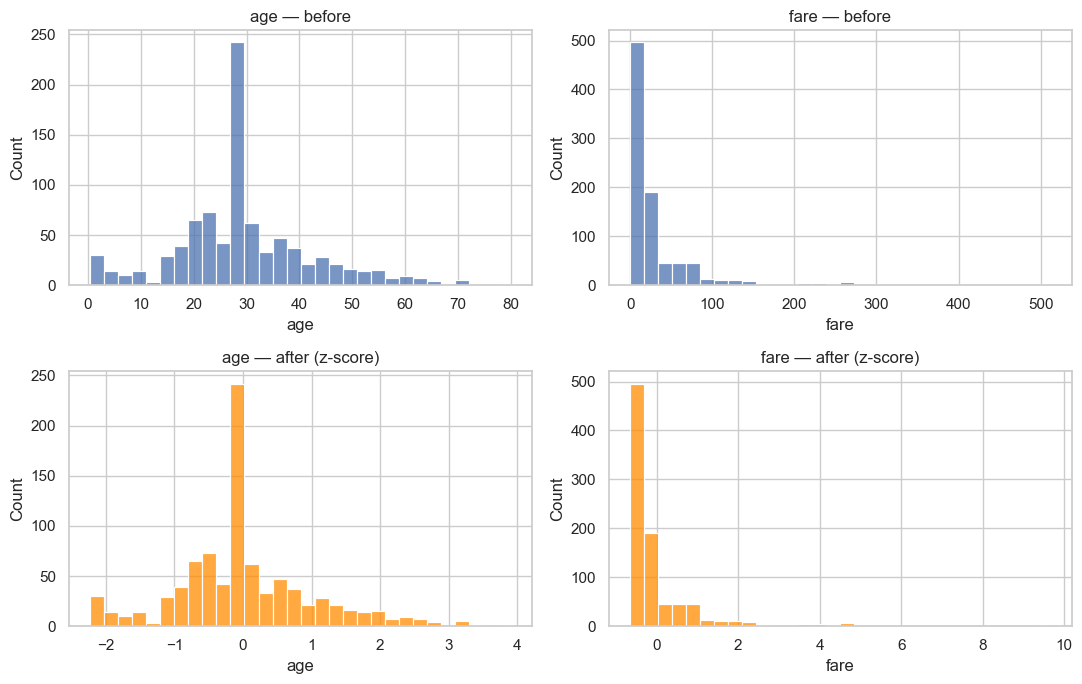

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for j, col in enumerate(["age", "fare"]):
    sns.histplot(clean[col], bins=30, ax=axes[0, j]); axes[0, j].set_title(f"{col} — before")
    sns.histplot(z[col], bins=30, ax=axes[1, j], color="darkorange"); axes[1, j].set_title(f"{col} — after (z-score)")
plt.tight_layout(); save_fig(fig, "zscore_before_after"); plt.show()

In [29]:
say("**Standardisation check.** After the z-score transform, `age` has mean "
    f"{z['age'].mean():.2e} and std {z['age'].std(ddof=0):.4f}; `fare` has mean {z['fare'].mean():.2e} and std {z['fare'].std(ddof=0):.4f} "
    "(population std, ddof = 0, as `StandardScaler` uses). Both are 0 / 1 up to floating-point error. "
    "The histograms keep exactly the same shape (in particular fare's long right tail) because z-scoring only shifts and rescales; it does not remove skew.")

**Standardisation check.** After the z-score transform, `age` has mean 2.72e-16 and std 1.0000; `fare` has mean 1.40e-16 and std 1.0000 (population std, ddof = 0, as `StandardScaler` uses). Both are 0 / 1 up to floating-point error. The histograms keep exactly the same shape (in particular fare's long right tail) because z-scoring only shifts and rescales; it does not remove skew.

In [30]:
with open("results/01_eda_interpretations.md", "w", encoding="utf-8") as fh:
    fh.write("# EDA written interpretations (auto-generated by 01_eda.ipynb)\n\n" + "\n\n".join(REPORT) + "\n")
print("saved results/01_eda_interpretations.md  ·  titanic.csv is ready for 02_modeling.ipynb")

saved results/01_eda_interpretations.md  ·  titanic.csv is ready for 02_modeling.ipynb
